In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
import joblib

In [55]:
df = pd.read_csv("../data/processed/super_master_dataset.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp')

In [56]:
ann_model = load_model(
    "../models/ann_model.h5",
    compile=False
)

lstm_model = load_model(
    "../models/lstm_model.h5",
    compile=False
)

In [57]:
import joblib

scaler = joblib.load("../models/feature_scaler.pkl")

print("Scaler loaded successfully!")

Scaler loaded successfully!


In [58]:
X = df.drop(columns=['ITS_Energy (kWh)', 'timestamp'])
y = df['ITS_Energy (kWh)']

X_scaled = scaler.transform(X)

In [59]:
ann_pred = ann_model.predict(X_scaled)

603/603 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [60]:
TIME_STEPS = 24

X_seq = []
y_seq = []

for i in range(len(X_scaled) - TIME_STEPS):
    X_seq.append(X_scaled[i:i+TIME_STEPS])
    y_seq.append(y.iloc[i+TIME_STEPS])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

lstm_pred = lstm_model.predict(X_seq)

602/602 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step


In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"{name}")
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R2  :", r2)
    print("-"*30)

evaluate(y, ann_pred, "ANN")
evaluate(y_seq, lstm_pred, "LSTM")

ANN
MAE : 46477.01823677139
RMSE: 64015.24820345413
R2  : -1.114676395403503
------------------------------
LSTM
MAE : 46534.93837425958
RMSE: 64055.117728296915
R2  : -1.117617778014404
------------------------------


In [62]:
results = pd.DataFrame({
    "Model": ["ANN", "LSTM"],
    "MAE": [
        mean_absolute_error(y, ann_pred),
        mean_absolute_error(y_seq, lstm_pred)
    ],
    "RMSE": [
        math.sqrt(mean_squared_error(y, ann_pred)),
        math.sqrt(mean_squared_error(y_seq, lstm_pred))
    ],
    "R2": [
        r2_score(y, ann_pred),
        r2_score(y_seq, lstm_pred)
    ]
})

results

results.to_csv(
    "../result/evaluation_results.csv",
    index=False
)

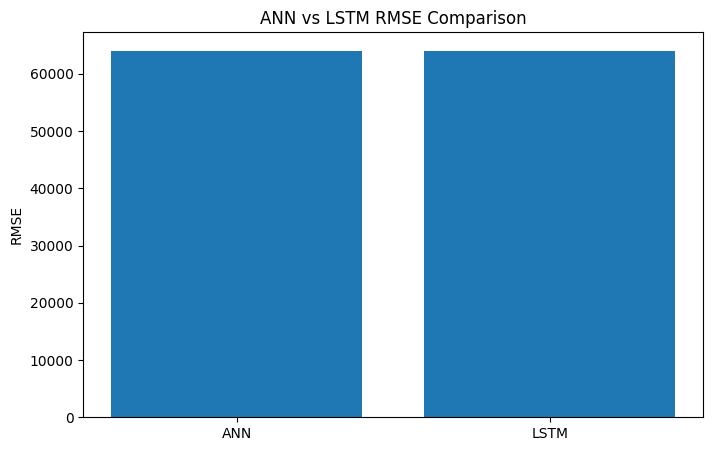

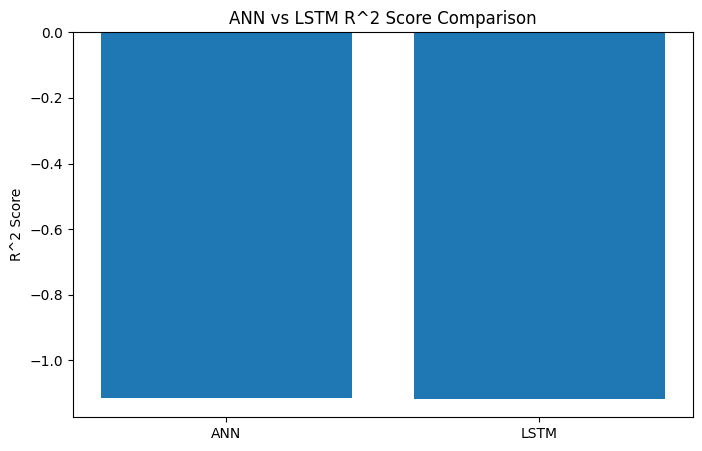

In [63]:


plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["RMSE"])
plt.title("ANN vs LSTM RMSE Comparison")
plt.ylabel("RMSE")

plt.savefig(
    "../result/graphs/model_comparison.png",
    dpi=300,
    bbox_inches='tight'
)

# R^2 Score Comparison 
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["R2"])
plt.title("ANN vs LSTM R^2 Score Comparison")
plt.ylabel("R^2 Score")


plt.savefig(
    "../result/graphs/r2_comparison.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [49]:
initial_seq = X_seq[-1]

future_preds = []

current_seq = initial_seq.copy()

for i in range(8760):

    pred = lstm_model.predict(
        current_seq.reshape(1,24,-1),
        verbose=0
    )[0][0]

    future_preds.append(pred)

    new_row = current_seq[-1].copy()

    new_row[0] = pred

    current_seq = np.vstack([
        current_seq[1:],
        new_row
    ])

    # SHOW PROGRESS
    if i % 100 == 0:

        print(f"Completed {i}/8760")

Completed 0/8760
Completed 100/8760
Completed 200/8760
Completed 300/8760
Completed 400/8760
Completed 500/8760
Completed 600/8760
Completed 700/8760
Completed 800/8760
Completed 900/8760
Completed 1000/8760
Completed 1100/8760
Completed 1200/8760
Completed 1300/8760
Completed 1400/8760
Completed 1500/8760
Completed 1600/8760
Completed 1700/8760
Completed 1800/8760
Completed 1900/8760
Completed 2000/8760
Completed 2100/8760
Completed 2200/8760
Completed 2300/8760
Completed 2400/8760
Completed 2500/8760
Completed 2600/8760
Completed 2700/8760
Completed 2800/8760
Completed 2900/8760
Completed 3000/8760
Completed 3100/8760
Completed 3200/8760
Completed 3300/8760
Completed 3400/8760
Completed 3500/8760
Completed 3600/8760
Completed 3700/8760
Completed 3800/8760
Completed 3900/8760
Completed 4000/8760
Completed 4100/8760
Completed 4200/8760
Completed 4300/8760
Completed 4400/8760
Completed 4500/8760
Completed 4600/8760
Completed 4700/8760
Completed 4800/8760
Completed 4900/8760
Completed 50

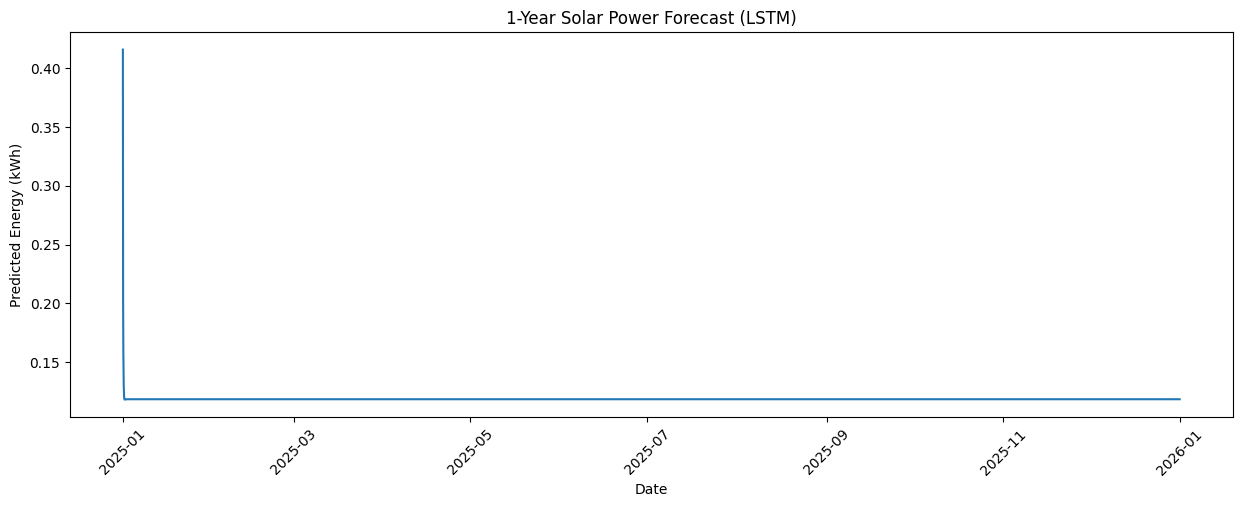

Graph saved successfully!


In [52]:
import os
import matplotlib.pyplot as plt
import pandas as pd

# CREATE FOLDER
os.makedirs("../result/graphs", exist_ok=True)

# CREATE FUTURE DATES
future_dates = pd.date_range(
    start=df['timestamp'].iloc[-1],
    periods=len(future_preds),
    freq='h'
)

# PLOT
plt.figure(figsize=(15,5))

plt.plot(future_dates, future_preds)

plt.title("1-Year Solar Power Forecast (LSTM)")

plt.xlabel("Date")

plt.ylabel("Predicted Energy (kWh)")

plt.xticks(rotation=45)

# SAVE GRAPH
plt.savefig(
    "../result/graphs/lstm_1year_forecast.png",
    dpi=300,
    bbox_inches='tight'
)

# SHOW
plt.show()

print("Graph saved successfully!")

In [53]:
pd.DataFrame({
    "timestamp": future_dates,
    "predicted_energy": future_preds
}).to_csv("../result/final_1year_forecast_1.csv", index=False)